# ResNet50 Transfer Learning - Improved Version

This notebook trains the **ResNet50 model** with all accuracy improvements applied:
- **ImageNet Normalization** — Aligns input distribution with ResNet50's pre-trained BatchNorm statistics
- **RandomResizedCrop** — Teaches multi-scale feature recognition
- **Optimal Threshold** — Automatically finds the best classification threshold instead of using a fixed 0.5
- **Unfreeze layer3 + layer4** — Deeper fine-tuning with 3-level differential learning rates

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Geographic Data Split (No Data Leakage)

In [2]:
metadata_path = 'dataset_version_2/metadata.csv'
df = pd.read_csv(metadata_path)
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Total valid images: {len(df)}')

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['landslide_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['landslide_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f'Train size: {len(df_train)} | Val size: {len(df_val)} | Test size: {len(df_test)}')

Total valid images: 8338
Train size: 5836 | Val size: 1255 | Test size: 1247


## 2. Dataset with Improved Augmentation

In [3]:
class LandslideDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = float(self.dataframe.iloc[idx]['label'])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# IMPROVEMENT 1: ImageNet normalization + RandomResizedCrop
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # Multi-scale learning
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),   # Overhead images: no canonical 'up'
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

batch_size = 32
train_loader = DataLoader(LandslideDataset(df_train, train_transform), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(LandslideDataset(df_val, val_test_transform), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(LandslideDataset(df_test, val_test_transform), batch_size=batch_size, shuffle=False)

## 3. Training & Evaluation Functions

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=20, patience=5, save_path='best_model.pth'):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(epoch_val_loss)
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered!')
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    return model


def find_optimal_threshold(model):
    """Find best classification threshold from validation set."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels).flatten()
    y_prob = np.array(all_probs).flatten()

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[f1_scores[:-1].argmax()]
    print(f'Optimal threshold (from val set): {best_threshold:.4f}')
    return best_threshold


def evaluate_model(model, name, threshold=0.5):
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_targets.extend(labels.numpy())

    y_true = np.array(test_targets).flatten()
    y_prob = np.array(test_preds).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n{'='*40}\n--- Evaluation: {name} (threshold={threshold:.3f}) ---\n{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['No Landslide', 'Landslide']))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_prob)

    print(f'Specificity:  {specificity:.4f}')
    print(f'ROC-AUC:      {auc:.4f}')
    print(f'TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Landslide', 'Landslide'],
                yticklabels=['No Landslide', 'Landslide'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'saved_models/{name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    return {'name': name, 'f1': f1_score(y_true, y_pred, pos_label=1), 'auc': auc,
            'specificity': specificity, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}


## 4. ResNet50 Model — Stage 1 (Head Only)

In [5]:
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze the entire base
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace classification head
resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)
resnet_model = resnet_model.to(device)

# Class imbalance handling
pos_count = df_train['label'].sum()
neg_count = len(df_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_res = optim.Adam(resnet_model.fc.parameters(), lr=1e-4)
scheduler_res = optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, mode='min', factor=0.5, patience=3)

print('Stage 1: Training ResNet50 (Head only)...')
resnet_model = train_model(resnet_model, criterion, optimizer_res, scheduler_res,
                           num_epochs=20, patience=6,
                           save_path='saved_models/resnet50_new_stage1.pth')

Stage 1: Training ResNet50 (Head only)...
Epoch 1/20 | Train Loss: 0.6909 | Val Loss: 0.6864
Epoch 2/20 | Train Loss: 0.6824 | Val Loss: 0.6816
Epoch 3/20 | Train Loss: 0.6745 | Val Loss: 0.6770
Epoch 4/20 | Train Loss: 0.6702 | Val Loss: 0.6712
Epoch 5/20 | Train Loss: 0.6669 | Val Loss: 0.6697
Epoch 6/20 | Train Loss: 0.6661 | Val Loss: 0.6679
Epoch 7/20 | Train Loss: 0.6642 | Val Loss: 0.6668
Epoch 8/20 | Train Loss: 0.6606 | Val Loss: 0.6643
Epoch 9/20 | Train Loss: 0.6620 | Val Loss: 0.6641
Epoch 10/20 | Train Loss: 0.6595 | Val Loss: 0.6613
Epoch 11/20 | Train Loss: 0.6586 | Val Loss: 0.6616
Epoch 12/20 | Train Loss: 0.6559 | Val Loss: 0.6605
Epoch 13/20 | Train Loss: 0.6565 | Val Loss: 0.6604
Epoch 14/20 | Train Loss: 0.6533 | Val Loss: 0.6601
Epoch 15/20 | Train Loss: 0.6477 | Val Loss: 0.6573
Epoch 16/20 | Train Loss: 0.6510 | Val Loss: 0.6562
Epoch 17/20 | Train Loss: 0.6498 | Val Loss: 0.6548
Epoch 18/20 | Train Loss: 0.6495 | Val Loss: 0.6568
Epoch 19/20 | Train Loss: 0.647

## 5. Stage 2 — Unfreeze layer3 + layer4 with 3-level Differential Learning Rates

In [6]:
print('Stage 2: Fine-tuning ResNet50 (layer3 + layer4 + fc)...')

# IMPROVEMENT: Unfreeze layer3 AND layer4 (deeper adaptation)
for name, child in resnet_model.named_children():
    if name in ['layer3', 'layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True

# IMPROVEMENT: 3-level differential learning rates
optimizer_ft = optim.Adam([
    {'params': resnet_model.layer3.parameters(), 'lr': 5e-6},  # Deeper pre-trained: very small LR
    {'params': resnet_model.layer4.parameters(), 'lr': 1e-5},  # Top pre-trained: small LR
    {'params': resnet_model.fc.parameters(),     'lr': 1e-4}   # New head: standard LR
])
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=3)

resnet_model = train_model(resnet_model, criterion, optimizer_ft, scheduler_ft,
                           num_epochs=15, patience=5,
                           save_path='saved_models/resnet50_new_best.pth')

Stage 2: Fine-tuning ResNet50 (layer3 + layer4 + fc)...
Epoch 1/15 | Train Loss: 0.6470 | Val Loss: 0.6488
Epoch 2/15 | Train Loss: 0.6437 | Val Loss: 0.6459
Epoch 3/15 | Train Loss: 0.6353 | Val Loss: 0.6426
Epoch 4/15 | Train Loss: 0.6329 | Val Loss: 0.6411
Epoch 5/15 | Train Loss: 0.6325 | Val Loss: 0.6350
Epoch 6/15 | Train Loss: 0.6261 | Val Loss: 0.6336
Epoch 7/15 | Train Loss: 0.6231 | Val Loss: 0.6286
Epoch 8/15 | Train Loss: 0.6249 | Val Loss: 0.6351
Epoch 9/15 | Train Loss: 0.6203 | Val Loss: 0.6243
Epoch 10/15 | Train Loss: 0.6146 | Val Loss: 0.6254
Epoch 11/15 | Train Loss: 0.6122 | Val Loss: 0.6241
Epoch 12/15 | Train Loss: 0.6125 | Val Loss: 0.6238
Epoch 13/15 | Train Loss: 0.6071 | Val Loss: 0.6236
Epoch 14/15 | Train Loss: 0.6034 | Val Loss: 0.6284
Epoch 15/15 | Train Loss: 0.6029 | Val Loss: 0.6272


## 6. Find Optimal Threshold & Evaluate

Optimal threshold (from val set): 0.2392

--- Evaluation with Default Threshold (0.5) ---

--- Evaluation: ResNet50 Improved (t=0.5) (threshold=0.500) ---
              precision    recall  f1-score   support

No Landslide       0.66      0.58      0.62       620
   Landslide       0.63      0.71      0.67       627

    accuracy                           0.64      1247
   macro avg       0.65      0.64      0.64      1247
weighted avg       0.65      0.64      0.64      1247

Specificity:  0.5806
ROC-AUC:      0.6974
TP: 444  TN: 360  FP: 260  FN: 183


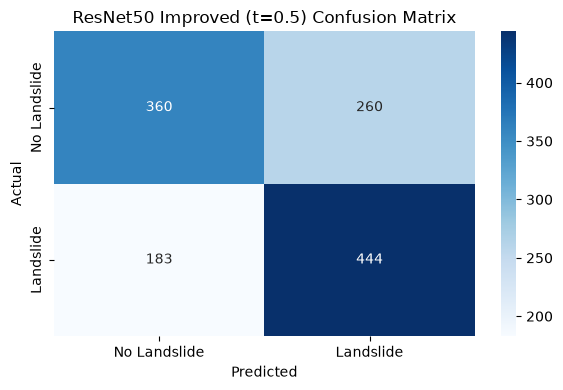


--- Evaluation with Optimal Threshold ---

--- Evaluation: ResNet50 Improved (Optimal Threshold) (threshold=0.239) ---
              precision    recall  f1-score   support

No Landslide       0.89      0.22      0.36       620
   Landslide       0.56      0.97      0.71       627

    accuracy                           0.60      1247
   macro avg       0.72      0.60      0.53      1247
weighted avg       0.72      0.60      0.53      1247

Specificity:  0.2242
ROC-AUC:      0.6974
TP: 609  TN: 139  FP: 481  FN: 18


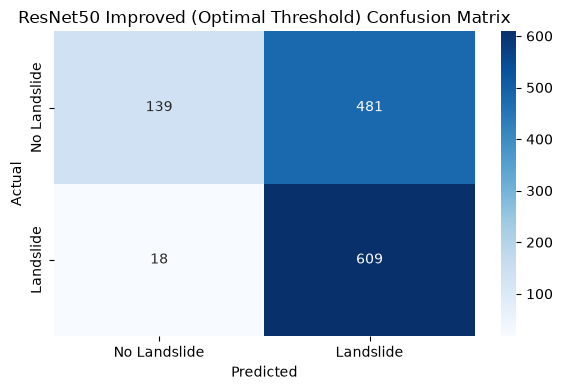


Default Threshold Results: {'name': 'ResNet50 Improved (t=0.5)', 'f1': 0.667167543200601, 'auc': 0.697363276225755, 'specificity': np.float64(0.5806451612903226), 'tp': np.int64(444), 'tn': np.int64(360), 'fp': np.int64(260), 'fn': np.int64(183)}
Optimal Threshold Results: {'name': 'ResNet50 Improved (Optimal Threshold)', 'f1': 0.7093768200349446, 'auc': 0.697363276225755, 'specificity': np.float64(0.22419354838709676), 'tp': np.int64(609), 'tn': np.int64(139), 'fp': np.int64(481), 'fn': np.int64(18)}


In [7]:
# IMPROVEMENT: Find optimal threshold from validation set (not fixed 0.5)
optimal_threshold = find_optimal_threshold(resnet_model)

print('\n--- Evaluation with Default Threshold (0.5) ---')
results_default = evaluate_model(resnet_model, 'ResNet50 Improved (t=0.5)', threshold=0.5)

print('\n--- Evaluation with Optimal Threshold ---')
results_optimal = evaluate_model(resnet_model, 'ResNet50 Improved (Optimal Threshold)', threshold=optimal_threshold)

print('\nDefault Threshold Results:', results_default)
print('Optimal Threshold Results:', results_optimal)